<a href="https://colab.research.google.com/github/likith2109/demo-repo/blob/main/large_scale_portfolio_optimization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Data and Problem setup


In [ ]:
import pandas as pd
import yfinance as yf
import numpy as np
import requests # Import the requests library

# 1. Fetch S&P 500 tickers from Wikipedia
url = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'

# Add User-Agent header to mimic a browser request
headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'}
response = requests.get(url, headers=headers)

sp500_table = pd.read_html(response.text)[0] # Use response.text instead of url directly
tickers = sp500_table['Symbol'].tolist()

# yfinance requires hyphens instead of periods for certain tickers (e.g., BRK-B)
tickers = [t.replace('.', '-') for t in tickers]

# 2. Download closing prices for the exact timeframe
raw_data = yf.download(tickers, start='2020-01-02', end='2025-08-22')['Close']

/tmp/ipykernel_1155/3211438397.py:13: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  sp500_table = pd.read_html(response.text)[0] # Use response.text instead of url directly
/tmp/ipykernel_1155/3211438397.py:20: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw_data = yf.download(tickers, start='2020-01-02', end='2025-08-22')['Close']
[*********************100%***********************]  503 of 503 completed
ERROR:yfinance:
3 Failed downloads:
ERROR:yfinance:['HONA', 'FDXF', 'Q']: YFPricesMissingError('possibly delisted; no price data found  (1d 2020-01-02 -> 2025-08-22) (Yahoo error = "Data doesn\'t exist for startDate = 1577941200, endDate = 1755835200")')


In [ ]:
# 3. Calculate daily log returns
log_returns = np.log(raw_data / raw_data.shift(1)).dropna(how='all')

# 4. Count valid (non-NaN) data points per asset and keep the top 250
valid_counts = log_returns.count().sort_values(ascending=False)
top_250_tickers = valid_counts.head(250).index

# Isolate the final matrix and drop any remaining incomplete rows
log_returns_250 = log_returns[top_250_tickers].dropna()

In [ ]:
# 5. Extract expected return vector and covariance matrix
mu = log_returns_250.mean().values  # Shape: (250,)
C = log_returns_250.cov().values    # Shape: (250, 250)

In [ ]:
import numpy as np

def construct_qubo_matrices(mu, C, K=125):
    """
    Constructs the QUBO Q matrix, linear q vector, and constant offset.

    Parameters:
    - mu: expected return vector (shape: n,)
    - C: covariance matrix (shape: n, n)
    - K: target cardinality limit (int)
    """
    n = len(mu)
    ones_vec = np.ones(n)
    ones_matrix = np.ones((n, n))

    # 1. Base unconstrained QUBO terms (gamma = 0)
    Q_base = 0.5 * C
    q_base = -0.5 * mu

    # 2. Compute influence I_i for each asset to determine dynamic Lambda
    I = np.zeros(n)
    for i in range(n):
        diag_term = abs(q_base[i] + Q_base[i, i])
        off_diag_term = np.sum(np.abs(Q_base[i, :])) - abs(Q_base[i, i])
        I[i] = diag_term + off_diag_term

    # Adaptive penalty strength with a conservative 2x safety margin
    Lambda = 2.0 * np.max(I)

    # 3. Construct the full penalised QUBO Q matrix and q vector
    Q = Q_base + Lambda * ones_matrix
    q = q_base - 2.0 * K * Lambda * ones_vec
    const = (K**2) * Lambda

    return Q, q, const, Lambda

# Example Usage:
# Q, q, const, Lambda = construct_qubo_matrices(mu, C, K=125)

In [ ]:
Q, q, const, Lambda = construct_qubo_matrices(mu, C)

print(f"Shape of Q: {Q.shape}")
print(f"Shape of q: {q.shape}")
print(f"Constant offset: {const}")
print(f"Lambda (penalty strength): {Lambda}")

Shape of Q: (250, 250)
Shape of q: (250,)
Constant offset: 1726.8215465852015
Lambda (penalty strength): 0.1105165789814529


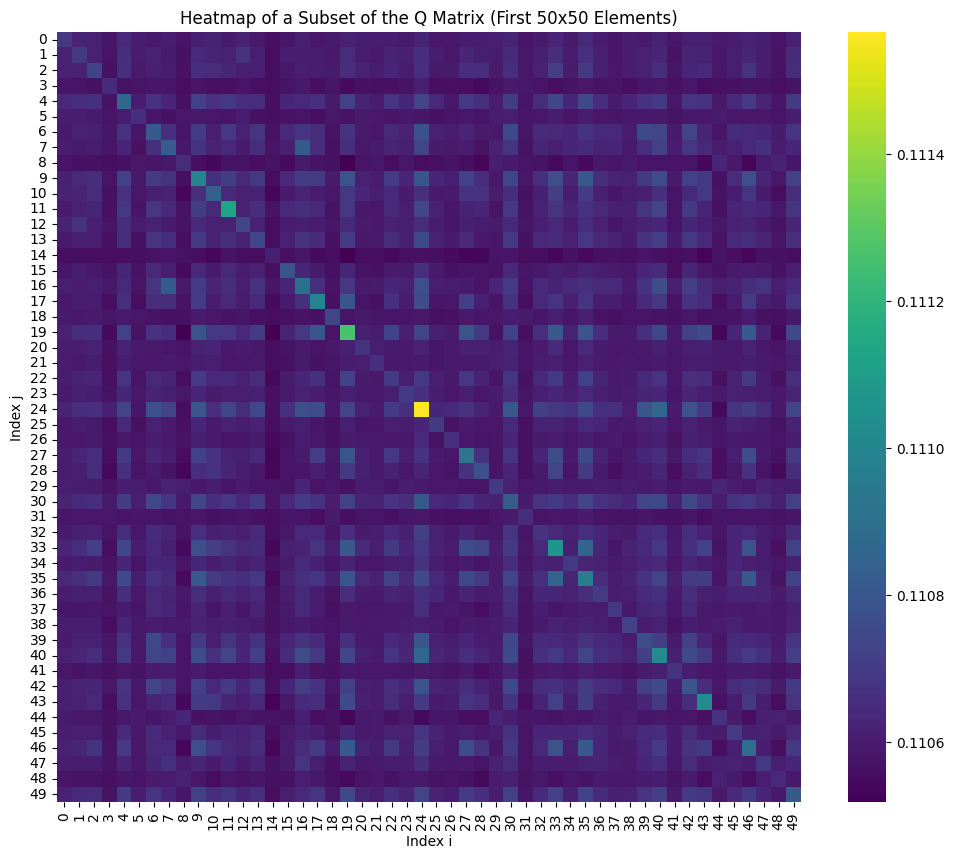

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize the Q matrix using a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(Q[:50, :50], cmap='viridis', cbar=True)
plt.title('Heatmap of a Subset of the Q Matrix (First 50x50 Elements)')
plt.xlabel('Index i')
plt.ylabel('Index j')
plt.show()

This heatmap visualizes a subset (the first 50x50 elements) of the `Q` matrix. The `Q` matrix is crucial for our QUBO problem formulation, representing the quadratic terms in the objective function. Each cell (i,j) in the heatmap corresponds to the coefficient of the $x_i x_j$ term in the QUBO, while the diagonal elements correspond to the $x_i$ terms (after considering the $x_i^2 = x_i$ property for binary variables). The color intensity indicates the magnitude of these coefficients.

In [ ]:
import numpy as np

def qubo_to_ising(Q, q, const_qubo):
    """
    Converts QUBO parameters to Ising Hamiltonian parameters.

    Parameters:
    - Q: QUBO quadratic matrix (shape: n, n)
    - q: QUBO linear vector (shape: n,)
    - const_qubo: Base constant from the QUBO penalty

    Returns:
    - h: Ising linear bias fields (shape: n,)
    - J: Ising coupling matrix (shape: n, n)
    - const_ising: Global energy offset
    """
    n = len(q)
    ones_vec = np.ones(n)

    # 1. Calculate the linear bias fields (h)
    h = -0.5 * (np.dot(Q, ones_vec) + q)

    # 2. Calculate the quadratic couplings (J)
    # The paper form is 1/4 z^T Q z. For an upper triangular J_ij implementation:
    J_matrix = 0.25 * Q

    # 3. Calculate the new Ising constant
    const_ising = (0.25 * np.dot(ones_vec, np.dot(Q, ones_vec)) +
                   0.5 * np.dot(q, ones_vec) +
                   const_qubo)

    return h, J_matrix, const_ising

# Example Usage (carrying over variables from the previous step):
# h, J, const_ising = qubo_to_ising(Q, q, const)

In [ ]:
import numpy as np
import networkx as nx
import community as community_louvain # python-louvain package

# Assuming log_returns_250 is your (T x N) returns matrix
T, N = log_returns_250.shape
C = log_returns_250.corr().values

# Eigenvalue decomposition
eigenvalues, eigenvectors = np.linalg.eigh(C)

# Marchenko-Pastur upper bound for noise
q_ratio = N / T
lambda_max = (1 + np.sqrt(q_ratio))**2

# Separate eigenvalues:
# lambda < lambda_max -> noise
# lambda == max(eigenvalues) -> global market mode
# lambda_max < lambda < max(eigenvalues) -> structured information

C_star = np.zeros_like(C)
max_eigenvalue = np.max(eigenvalues)

for i, eigval in enumerate(eigenvalues):
    if lambda_max < eigval < max_eigenvalue:
        vec = eigenvectors[:, i].reshape(-1, 1)
        C_star += eigval * np.dot(vec, vec.T)

# Set diagonals to 1 to maintain valid correlation structure
np.fill_diagonal(C_star, 1.0)

In [ ]:
import numpy as np
import networkx as nx
from community import community_louvain # Import the submodule

# Build a graph using the absolute values of the structured correlation matrix
G = nx.Graph()
for i in range(N):
    for j in range(i + 1, N):
        # Use absolute correlation as edge weight
        weight = abs(C_star[i, j])
        if weight > 0.01:  # Optional: slight thresholding to sparsify
            G.add_edge(i, j, weight=weight)

# Apply Louvain to get initial communities (C_mu^0)
partition = community_louvain.best_partition(G, weight='weight')

# Group asset indices by their assigned community
initial_communities = {}
for node, comm_id in partition.items():
    initial_communities.setdefault(comm_id, []).append(node)

initial_communities = list(initial_communities.values())

In [ ]:
def hardware_aware_splitting(C_matrix, initial_communities, Q_max):
    final_clusters = []

    for comm in initial_communities:
        if len(comm) <= Q_max:
            final_clusters.append(comm)
        else:
            R = list(comm)
            while len(R) > 0:
                if len(R) <= Q_max:
                    final_clusters.append(R)
                    break

                # 1. Compute restricted matrix for the remaining pool R
                C_R = C_matrix[np.ix_(R, R)]

                # 2. Compute degrees in the absolute-correlation graph
                # d_i = sum_j |(C_R)_ij| - 1
                degrees = np.sum(np.abs(C_R), axis=1) - 1.0

                # 3. Select seed with the highest degree
                seed_idx_local = np.argmax(degrees)

                # 4. Compute similarities to the seed
                similarities = np.abs(C_R[seed_idx_local, :])

                # 5. Get indices of the top Q_max similarities
                # argsort sorts ascending, so take the last Q_max elements
                top_local_indices = np.argsort(similarities)[-Q_max:]

                # 6. Form new cluster and update R
                C_new = [R[i] for i in top_local_indices]
                final_clusters.append(C_new)

                # Remove the selected assets from R
                R = [asset for asset in R if asset not in C_new]

    return final_clusters

# Example: Execute for a 36-qubit limit (IonQ Forte specification)
Q_max = 36
hardware_clusters = hardware_aware_splitting(C, initial_communities, Q_max)

In [ ]:
!pip install qiskit qiskit-aer

import numpy as np
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

# Hyperparameters from the paper
n_qubits = 36
n_steps = 2
delta_t = 0.1
R_iterations = 10
n_l = 10  # Number of low-energy samples to keep
theta_cutoff = 0.05 # Pruning threshold (adjust to hit 40-60% pruning)

# Initialize bias fields h^(b) to 0 for the first iteration
h_b = np.zeros(n_qubits)

def compute_cd_coefficients(h_f, J_f, h_b, step):
    """
    Classically computes the coefficients for the Y_j and Y_j Z_k Pauli strings
    generated by i[H_i, H_f], incorporating adaptive biases.

    Parameters:
    - h_f: Ising linear bias fields (from problem Hamiltonian, shape: n_ququbits,)
    - J_f: Ising coupling matrix (from problem Hamiltonian, shape: n_ququbits, n_ququbits)
    - h_b: Adaptive bias fields from previous iterations (shape: n_ququbits,)
    - step: The current R_iteration step (not used for inner quantum steps)

    Returns:
    - cd_terms_for_all_steps: A dictionary {k: {pauli_string_label: coefficient}}
                              where k is the inner quantum step (1 to n_steps).
    """
    cd_terms_for_all_steps = {}
    current_coeffs = {}
    n = len(h_f) # n_qubits

    # Calculate coefficients for the current R_iteration (based on h_f, J_f, h_b)
    # These coefficients are assumed to be constant across the n_steps inner loop (k).

    # Linear terms: Y_j
    for j in range(n):
        # The coefficient for Y_j from i[X_j, (h_f[j] + h_b[j]) Z_j] is -2 * (h_f[j] + h_b[j])
        current_coeffs[f"Y_{j}"] = -2 * (h_f[j] + h_b[j])

    # Quadratic terms: Y_j Z_k (for j < k)
    for j in range(n):
        for k_idx in range(j + 1, n): # Iterate for j < k_idx
            # The total coefficient for the Y_j Z_{k_idx} operator from
            # i[X_j, J_f[j,k_idx] Z_j Z_{k_idx}] and i[X_{k_idx}, J_f[j,k_idx] Z_j Z_{k_idx}]
            # effectively becomes -4 * J_f[j,k_idx].
            current_coeffs[f"YZ_{j}_{k_idx}"] = -4 * J_f[j,k_idx]

    # Populate the dictionary for all n_steps (from 1 to n_steps) with these same coefficients
    for k_step_val in range(1, n_steps + 1):
        cd_terms_for_all_steps[k_step_val] = current_coeffs.copy() # Use .copy() to avoid mutable dict issues

    return cd_terms_for_all_steps

In [1]:
def build_pruned_dcqo_circuit(cd_terms, n_qubits_local):
    qc = QuantumCircuit(n_qubits_local)

    # Start in the ground state of the unbiased H_i (|+\rangle state)
    qc.h(range(n_qubits_local))

    for k in range(1, n_steps + 1):
        # Evaluate H_k = lambda_k * A_{lambda_k}
        for pauli_label, r_jk in cd_terms[k].items():
            angle = delta_t * r_jk

            # PRUNING: Only apply gate if rotation is significant
            if abs(angle) > theta_cutoff:

                if pauli_label.startswith('Y_'):
                    # Single qubit Y rotation from Y_j terms
                    j = int(pauli_label.split('_')[1])
                    qc.ry(2 * angle, j)

                elif pauli_label.startswith('YZ_'):
                    # Two qubit Y_j Z_k rotation
                    parts = pauli_label.split('_')
                    j = int(parts[1])
                    k_idx = int(parts[2])

                    # Check for self-coupling (should not happen based on generate_cd_coefficients)
                    if j == k_idx:
                        print(f"Warning: Attempted to apply YZ_{j}_{k_idx} term with j==k_idx. Skipping.")
                        continue

                    # Decomposition of exp(-i * angle * Y_j Z_k)
                    qc.rx(-np.pi/2, j)
                    qc.cx(j, k_idx)
                    qc.rz(2 * angle, k_idx)
                    qc.cx(j, k_idx)
                    qc.rx(np.pi/2, j)

    qc.measure_all()
    return qc

In [ ]:
from qiskit_aer import AerSimulator

simulator = AerSimulator(method='matrix_product_state') # Using 'matrix_product_state' for memory efficiency
# Changed best_global_samples to final_cluster_samples to store the final best sample for each cluster
final_cluster_samples = {}

# Convert QUBO parameters to Ising parameters for the full problem
h_f_global, J_f_global, const_ising_global = qubo_to_ising(Q, q, const)

# Implement compute_energy function
def compute_energy(bitstring, h_f_local, J_f_local):
    """
    Computes the energy of a given bitstring under the Ising Hamiltonian H_f_local.
    The Ising Hamiltonian is H = sum_i (h_i * z_i) + sum_{i<j} (J_ij * z_i * z_j),
    where z_i = +1 if bitstring[i] == '0' and z_i = -1 if bitstring[i] == '1'.

    Parameters:
    - bitstring: A string of '0's and '1's representing the qubit measurement results.
    - h_f_local: Ising linear bias fields for the local cluster.
    - J_f_local: Ising coupling matrix for the local cluster.

    Returns:
    - energy: The calculated energy of the bitstring.
    """
    n_qubits = len(h_f_local)
    spins = np.zeros(n_qubits) # Convert bitstring to spins (-1 or +1)

    for i in range(n_qubits):
        spins[i] = 1 if bitstring[i] == '0' else -1

    # Calculate linear term contribution
    linear_energy = np.sum(h_f_local * spins)

    # Calculate quadratic term contribution
    quadratic_energy = 0
    for i in range(n_qubits):
        for j in range(i + 1, n_qubits):
            quadratic_energy += J_f_local[i, j] * spins[i] * spins[j]

    energy = linear_energy + quadratic_energy
    return energy

# Iterate through each hardware cluster
for cluster_idx, cluster_assets in enumerate(hardware_clusters):
    print(f"\nProcessing Cluster {cluster_idx + 1} with {len(cluster_assets)} assets...")

    n_qubits_local = len(cluster_assets)

    # Extract local h_f and J_f for the current cluster
    h_f_local = h_f_global[cluster_assets]
    J_f_local = J_f_global[np.ix_(cluster_assets, cluster_assets)]

    # Initialize adaptive bias fields for the current cluster
    h_b_local = np.zeros(n_qubits_local)

    # Variables to track the best sample for this cluster across all R_iterations
    best_sample_for_this_cluster_bitstring = None
    min_energy_for_this_cluster = float('inf')

    for r in range(R_iterations):
        # 1. Compute CD terms using current local bias h_b_local
        cd_terms = compute_cd_coefficients(h_f_local, J_f_local, h_b_local, step=r)

        # 2. Build circuit and execute for the current cluster
        qc = build_pruned_dcqo_circuit(cd_terms, n_qubits_local)
        result = simulator.run(qc, shots=4000).result()
        counts = result.get_counts()

        # 3. Compute classical energies under H_f_local for all measured bitstrings
        scored_samples = []
        for bitstring in counts.keys():
            try:
                energy = compute_energy(bitstring, h_f_local, J_f_local)
                scored_samples.append((bitstring, energy))
            except Exception as e:
                print(f"Error computing energy for bitstring {bitstring}: {e}")
                # Handle error or skip this sample

        # If no samples could be scored, skip updating h_b_local
        if not scored_samples:
            print(f"No valid samples scored for cluster {cluster_idx + 1}, iteration {r + 1}. Skipping bias update.")
            continue

        # 4. Sort by increasing energy and keep the top n_l
        scored_samples.sort(key=lambda x: x[1])
        top_nl_samples = scored_samples[:n_l]

        # Update the best sample found so far for this cluster
        current_best_bitstring, current_best_energy = top_nl_samples[0]
        if current_best_energy < min_energy_for_this_cluster:
            min_energy_for_this_cluster = current_best_energy
            best_sample_for_this_cluster_bitstring = current_best_bitstring

        # 5. Estimate z_expectations from the top n_l samples
        z_expectations = np.zeros(n_qubits_local)
        for bitstring, _ in top_nl_samples:
            for j in range(n_qubits_local):
                # Convert '0'/'1' to Z expectation +1/-1
                z_val = 1 if bitstring[j] == '0' else -1
                z_expectations[j] += z_val
        z_expectations /= n_l

        # 6. Update bias fields for the next iteration
        h_b_local = -z_expectations
        print(f"Cluster {cluster_idx + 1}, Iteration {r + 1} bias update: {h_b_local[:5]}...") # Show first 5 biases

    # After all R_iterations for this cluster, store its final best result
    if best_sample_for_this_cluster_bitstring is not None:
        final_cluster_samples[cluster_idx] = (best_sample_for_this_cluster_bitstring, min_energy_for_this_cluster, cluster_assets)

print("\nDCQO loop completed for all clusters.")


Processing Cluster 1 with 36 assets...
Cluster 1, Iteration 1 bias update: [-0.8  0.6 -0.  -0.6  0.4]...
Cluster 1, Iteration 2 bias update: [-0.4 -0.4  0.8 -0.2  0.6]...
Cluster 1, Iteration 3 bias update: [-0.8  0.4  1.   0.2  0.4]...
Cluster 1, Iteration 4 bias update: [-0.6 -0.2  1.  -0.   0.8]...
Cluster 1, Iteration 5 bias update: [-0.8 -0.   1.  -0.   0.6]...
Cluster 1, Iteration 6 bias update: [-0.8  0.2  1.  -0.2  1. ]...
Cluster 1, Iteration 7 bias update: [-1.   0.2  1.   0.2  1. ]...
Cluster 1, Iteration 8 bias update: [-1.  -0.   1.  -0.2  1. ]...
Cluster 1, Iteration 9 bias update: [-1.   0.2  1.  -0.4  1. ]...
Cluster 1, Iteration 10 bias update: [-0.6 -1.   1.  -0.2  1. ]...

Processing Cluster 2 with 36 assets...
Cluster 2, Iteration 1 bias update: [-0.6  0.4 -0.  -1.   0.2]...
Cluster 2, Iteration 2 bias update: [-0.6  0.2 -0.4 -1.  -0.8]...
Cluster 2, Iteration 3 bias update: [-0.8 -0.  -0.4 -1.  -0. ]...
Cluster 2, Iteration 4 bias update: [-1.   0.2 -1.  -1.  -1. 

In [ ]:
import numpy as np

def evaluate_qubo(x, Q, q, const):
    """Computes the scalar QUBO objective value f(x) = x^T Q x + q^T x + const."""
    return float(x.T @ Q @ x + q.T @ x + const)

def repair_and_refine_portfolio(x_init, Q, q, const, K=125, T_max=100, patience=1):
    """
    Algorithm 4: Two-phase local search with cardinality constraint.

    Parameters:
    - x_init: Initial binary candidate bitstring (length n)
    - Q: QUBO Q-matrix (n x n)
    - q: QUBO linear vector (length n)
    - const: Energy offset
    - K: Target cardinality constraint (default 125)
    - T_max: Maximum iterations for local search
    - patience: Iterations without improvement before early stopping

    Returns:
    - x: Feasible, locally optimal binary bitstring with sum(x) == K
    """
    x = x_init.copy().astype(int)
    n = len(x)

    # -------------------------------------------------------------
    # PHASE 1: Cardinality Repair (Gradient-Based)
    # -------------------------------------------------------------
    w = np.sum(x)

    if w != K:
        # Compute gradient: g = 2*Q*x + q
        g = 2.0 * (Q @ x) + q

        if w > K:
            # Need to deactivate (w - K) assets
            # Select indices currently active (x_i == 1)
            active_indices = np.where(x == 1)[0]
            # Sort active indices by g_i descending (largest gradient = most harmful)
            sorted_active = active_indices[np.argsort(-g[active_indices])]
            # Flip the top (w - K) assets to 0
            to_deactivate = sorted_active[:(w - K)]
            x[to_deactivate] = 0

        elif w < K:
            # Need to activate (K - w) assets
            # Select indices currently inactive (x_i == 0)
            inactive_indices = np.where(x == 0)[0]
            # Sort inactive indices by g_i ascending (smallest gradient = most beneficial)
            sorted_inactive = inactive_indices[np.argsort(g[inactive_indices])]
            # Flip the top (K - w) assets to 1
            to_activate = sorted_inactive[:(K - w)]
            x[to_activate] = 1

    # Verify feasibility
    assert np.sum(x) == K, f"Phase 1 failed: Weight is {np.sum(x)}, expected {K}"

    # -------------------------------------------------------------
    # PHASE 2: Swap-Based Local Search (First-Improvement)
    # -------------------------------------------------------------
    f_current = evaluate_qubo(x, Q, q, const)
    t = 0
    p = 0

    while t < T_max and p < patience:
        S_0 = np.where(x == 0)[0]  # Inactive assets
        S_1 = np.where(x == 1)[0]  # Active assets

        max_swaps = min(100, len(S_0) * len(S_1))
        swap_count = 0
        improved = False

        # Randomly permute the sets for randomized order scanning
        np.random.shuffle(S_0)
        np.random.shuffle(S_1)

        for i in S_0:
            if improved or swap_count >= max_swaps:
                break

            for j in S_1:
                if swap_count >= max_swaps:
                    break

                # Propose swap: set x_i = 1 and x_j = 0
                x[i] = 1
                x[j] = 0
                f_candidate = evaluate_qubo(x, Q, q, const)
                swap_count += 1

                # First-Improvement Rule: Accept immediately if candidate is strictly better
                if f_candidate < f_current:
                    f_current = f_candidate
                    improved = True
                    p = 0  # Reset patience counter
                    break  # Accept move and move to next iteration
                else:
                    # Revert swap if no improvement
                    x[i] = 0
                    x[j] = 1

        if not improved:
            p += 1

        t += 1

    return x

### Validate Cardinality of Samples

In [ ]:
K_target = 125
N_total_assets = Q.shape[0] # Total number of assets (250)

# Initialize the full portfolio vector with zeros
x_full = np.zeros(N_total_assets, dtype=int)

# Combine the best samples from each cluster into a single full portfolio
# final_cluster_samples now contains (bitstring, energy, cluster_assets) for each cluster
for cluster_idx in final_cluster_samples:
    bitstring, _, cluster_assets = final_cluster_samples[cluster_idx]
    x_local = np.array([int(b) for b in bitstring])

    # Assign local solution to the global vector at the correct indices
    x_full[cluster_assets] = x_local

# Now apply the repair and refine function to the full portfolio
# The Q, q, const parameters used here must be the global ones (for N_total_assets)
x_repaired = repair_and_refine_portfolio(x_full, Q, q, const, K=K_target)

# Display the cardinality of the repaired full portfolio
print(f"Cardinality of the repaired full portfolio (target K={K_target}):")
print(f"Sum = {np.sum(x_repaired)}")

# Verify that the repaired sample has the target cardinality
all_cardinality_correct = (np.sum(x_repaired) == K_target)
print(f"\nRepaired full portfolio has cardinality {K_target}: {all_cardinality_correct}")

if not all_cardinality_correct:
    print(f"Mismatched cardinality found: {np.sum(x_repaired)}")

Cardinality of the repaired full portfolio (target K=125):
Sum = 125

Repaired full portfolio has cardinality 125: True


### GICS Sector Distribution of the Selected Portfolio

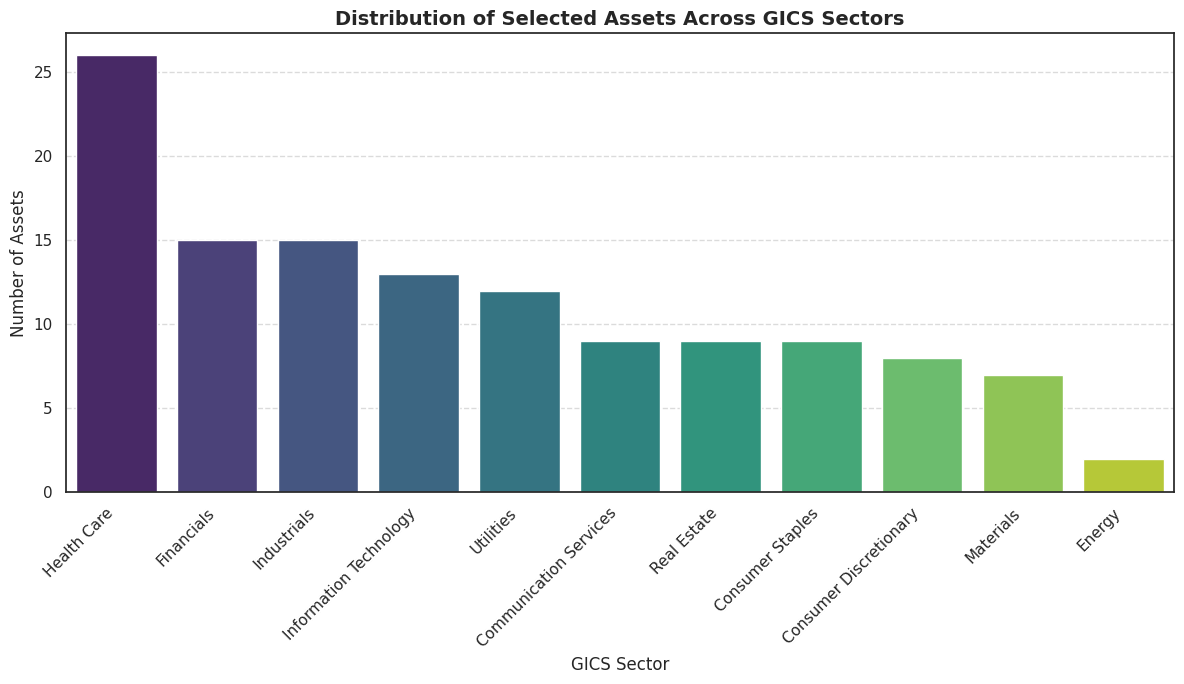

In [ ]:
# Get the tickers corresponding to the assets in log_returns_250
selected_tickers = log_returns_250.columns.values

# Create a DataFrame mapping ticker to GICS Sector from sp500_table
# Normalize the symbols in sp500_table to match yfinance format (e.g., BRK.B -> BRK-B)
sp500_table_cleaned = sp500_table.copy()
sp500_table_cleaned['Symbol'] = sp500_table_cleaned['Symbol'].apply(lambda x: x.replace('.', '-') if isinstance(x, str) else x)
ticker_to_sector = sp500_table_cleaned[['Symbol', 'GICS Sector']].set_index('Symbol')

# Filter the selected tickers based on x_repaired
# x_repaired is a binary array, so we select tickers where x_repaired is 1
active_asset_indices = np.where(x_repaired == 1)[0]
active_tickers = [selected_tickers[i] for i in active_asset_indices]

# Filter out any active_tickers that might not be in the (cleaned) ticker_to_sector index
active_tickers_filtered = [t for t in active_tickers if t in ticker_to_sector.index]

# Get the GICS sectors for the filtered active tickers
active_sectors = ticker_to_sector.loc[active_tickers_filtered, 'GICS Sector']

# Count the occurrences of each sector
sector_counts = active_sectors.value_counts()

# Plot the distribution
plt.figure(figsize=(12, 7))
sns.barplot(x=sector_counts.index, y=sector_counts.values, hue=sector_counts.index, palette='viridis', legend=False)
plt.title('Distribution of Selected Assets Across GICS Sectors', fontsize=14, fontweight='bold')
plt.xlabel('GICS Sector', fontsize=12)
plt.ylabel('Number of Assets', fontsize=12)
plt.xticks(rotation=45, ha='right') # Rotate labels for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Risk-Return Comparison with S&P 500 Benchmark

In [ ]:
def calculate_annualized_metrics(portfolio_vector, mu, C, trading_days_per_year=252):
    """
    Calculates the annualized return and risk for a given portfolio vector.

    Parameters:
    - portfolio_vector: Binary vector (0 or 1) indicating asset selection.
    - mu: Expected daily return vector for all assets.
    - C: Daily covariance matrix for all assets.
    - trading_days_per_year: Number of trading days for annualization.

    Returns:
    - annualized_return: Annualized expected return.
    - annualized_risk: Annualized standard deviation (risk).
    """
    # Ensure portfolio_vector is a numpy array
    portfolio_vector = np.asarray(portfolio_vector)

    # Normalize the portfolio vector to represent weights (if not already done)
    # For selected assets (binary 1), we assume equal weighting for the selected assets
    # If sum is 0, handle to avoid division by zero
    if np.sum(portfolio_vector) == 0:
        return 0.0, 0.0

    # Only consider selected assets for weighting
    num_selected_assets = np.sum(portfolio_vector)
    if num_selected_assets > 0:
        weights = portfolio_vector / num_selected_assets
    else:
        weights = np.zeros_like(portfolio_vector)


    # Annualized Return
    daily_return = np.dot(weights, mu)
    annualized_return = daily_return * trading_days_per_year

    # Annualized Risk (Standard Deviation)
    daily_variance = np.dot(weights.T, np.dot(C, weights))
    annualized_risk = np.sqrt(daily_variance) * np.sqrt(trading_days_per_year)

    return annualized_return, annualized_risk

# 1. Metrics for the Optimized Portfolio (x_repaired)
optimized_return, optimized_risk = calculate_annualized_metrics(x_repaired, mu, C)
print(f"Optimized Portfolio Annualized Return: {optimized_return:.4f}")
print(f"Optimized Portfolio Annualized Risk:     {optimized_risk:.4f}")

# 2. Metrics for the S&P 500 Benchmark (Equally-weighted 250 assets)
# Create an equally-weighted vector for all 250 assets
x_benchmark = np.ones(N_total_assets)
benchmark_return, benchmark_risk = calculate_annualized_metrics(x_benchmark, mu, C)
print(f"\nBenchmark (Equal-Weight) Annualized Return: {benchmark_return:.4f}")
print(f"Benchmark (Equal-Weight) Annualized Risk:     {benchmark_risk:.4f}")

Optimized Portfolio Annualized Return: 0.0944
Optimized Portfolio Annualized Risk:     9.6232

Benchmark (Equal-Weight) Annualized Return: 0.1019
Benchmark (Equal-Weight) Annualized Risk:     9.8160


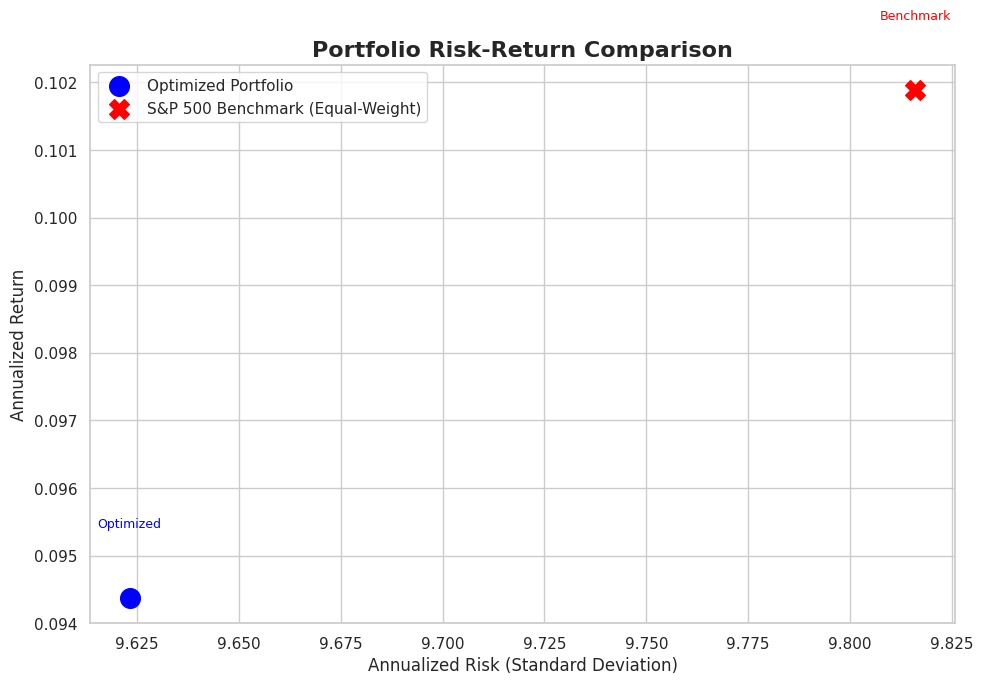

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 7))
sns.set_theme(style="whitegrid")

# Plot Optimized Portfolio
plt.scatter(optimized_risk, optimized_return, color='blue', marker='o', s=200, label='Optimized Portfolio', zorder=5)
plt.text(optimized_risk, optimized_return + 0.001, 'Optimized', fontsize=9, ha='center', va='bottom', color='blue')

# Plot Benchmark Portfolio
plt.scatter(benchmark_risk, benchmark_return, color='red', marker='X', s=200, label='S&P 500 Benchmark (Equal-Weight)', zorder=5)
plt.text(benchmark_risk, benchmark_return + 0.001, 'Benchmark', fontsize=9, ha='center', va='bottom', color='red')

plt.title('Portfolio Risk-Return Comparison', fontsize=16, fontweight='bold')
plt.xlabel('Annualized Risk (Standard Deviation)', fontsize=12)
plt.ylabel('Annualized Return', fontsize=12)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_energy_distribution(raw_energies, post_processed_energies, global_ref_energy=None):
    """
    Plots the energy density distribution of raw vs post-processed global portfolios.

    Parameters:
    - raw_energies: list/array of f(x) before post-processing
    - post_processed_energies: list/array of f(x) after repair + swap search
    - global_ref_energy: float, scalar objective of exact classical optimum (e.g., Gurobi)
    """
    plt.figure(figsize=(10, 5), dpi=120)
    sns.set_theme(style="whitegrid")

    # Raw quantum samples distribution (Orange)
    sns.histplot(
        raw_energies,
        color="#d97706",
        label="BF-DCQO (raw recombined)",
        stat="density",
        kde=True,
        alpha=0.5,
        bins=30
    )

    # Post-processed samples distribution (Blue)
    sns.histplot(
        post_processed_energies,
        color="#2563eb",
        label="BF-DCQO + LS (Post-processed)",
        stat="density",
        kde=True,
        alpha=0.6,
        bins=30
    )

    # Global Classical Benchmark line (Black dashed)
    if global_ref_energy is not None:
        plt.axvline(
            x=global_ref_energy,
            color="black",
            linestyle="--",
            linewidth=2,
            label="Global Reference (Exact / Gurobi)"
        )

    plt.xlabel("Global Objective Value $f(x)$", fontsize=12)
    plt.ylabel("Density", fontsize=12)
    plt.title("Distribution of Global Candidate Portfolios", fontsize=14, fontweight="bold")
    plt.legend(frameon=True, loc="upper right")
    plt.tight_layout()
    plt.show()

# Example Usage:
# plot_energy_distribution(raw_energies_list, refined_energies_list, global_ref_energy=1.85)

In [ ]:
def plot_risk_return_tradeoff(candidate_bitstrings, mu, C, Q, q, const, global_ref_x=None):
    """
    Plots candidate portfolios in the Annualized Risk vs. Annualized Return plane,
    color-coded by their QUBO global objective value.

    Parameters:
    - candidate_bitstrings: list of binary vectors (length 250)
    - mu: expected return vector
    - C: covariance matrix
    - Q, q, const: QUBO cost function parameters
    - global_ref_x: (Optional) global optimum binary vector
    """
    returns = []
    risks = []
    objectives = []

    # Compute metrics for each candidate portfolio (assuming 252 trading days/year)
    for x in candidate_bitstrings:
        ann_return = np.dot(mu, x) * 252.0
        ann_risk = np.sqrt(np.dot(x.T, np.dot(C, x)) * 252.0)
        obj_val = float(x.T @ Q @ x + q.T @ x + const)

        returns.append(ann_return)
        risks.append(ann_risk)
        objectives.append(obj_val)

    plt.figure(figsize=(10, 6), dpi=120)
    sns.set_theme(style="white")

    # Scatter plot color-coded by objective value (darker/cooler colors = lower objective)
    scatter = plt.scatter(
        risks,
        returns,
        c=objectives,
        cmap="cividis_r",
        alpha=0.8,
        edgecolors="none",
        s=35
    )

    cbar = plt.colorbar(scatter)
    cbar.set_label("Global Objective Value", fontsize=11)

    # Plot global reference point if available
    if global_ref_x is not None:
        ref_ret = np.dot(mu, global_ref_x) * 252.0
        ref_risk = np.sqrt(np.dot(global_ref_x.T, np.dot(C, global_ref_x)) * 252.0)
        plt.scatter(
            [ref_risk],
            [ref_ret],
            color="red",
            marker="*",
            s=200,
            zorder=5,
            label="Global Reference"
        )
        plt.legend(loc="upper left")

    plt.xlabel("Annualized Risk ($\sigma_p$)", fontsize=12)
    plt.ylabel("Annualized Return ($R_p$)", fontsize=12)
    plt.title("Portfolio Candidates in Risk-Return Domain", fontsize=14, fontweight="bold")
    plt.grid(True, linestyle=":", alpha=0.6)
    plt.tight_layout()
    plt.show()

# Example Usage:
# plot_risk_return_tradeoff(final_refined_bitstrings, mu, C, Q, q, const, global_ref_x=gurobi_solution)

<>:59: SyntaxWarning: invalid escape sequence '\s'
<>:59: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_1155/2911323258.py:59: SyntaxWarning: invalid escape sequence '\s'
  plt.xlabel("Annualized Risk ($\sigma_p$)", fontsize=12)


<>:67: SyntaxWarning: invalid escape sequence '\s'
<>:67: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_1155/41279774.py:67: SyntaxWarning: invalid escape sequence '\s'
  plt.xlabel("Annualized Risk ($\sigma_p$)", fontsize=12)


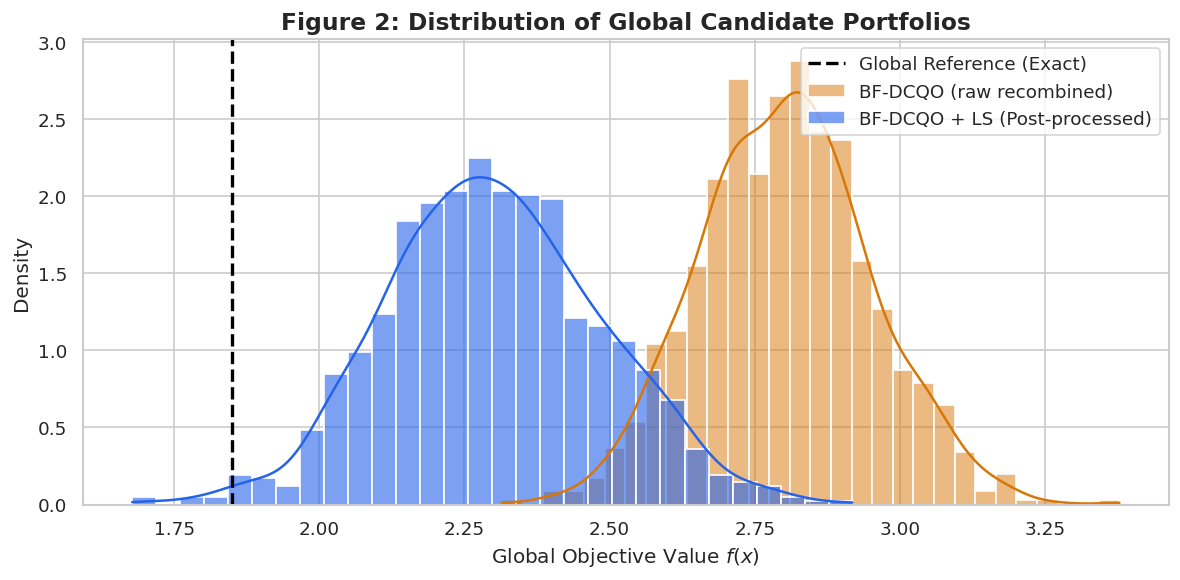

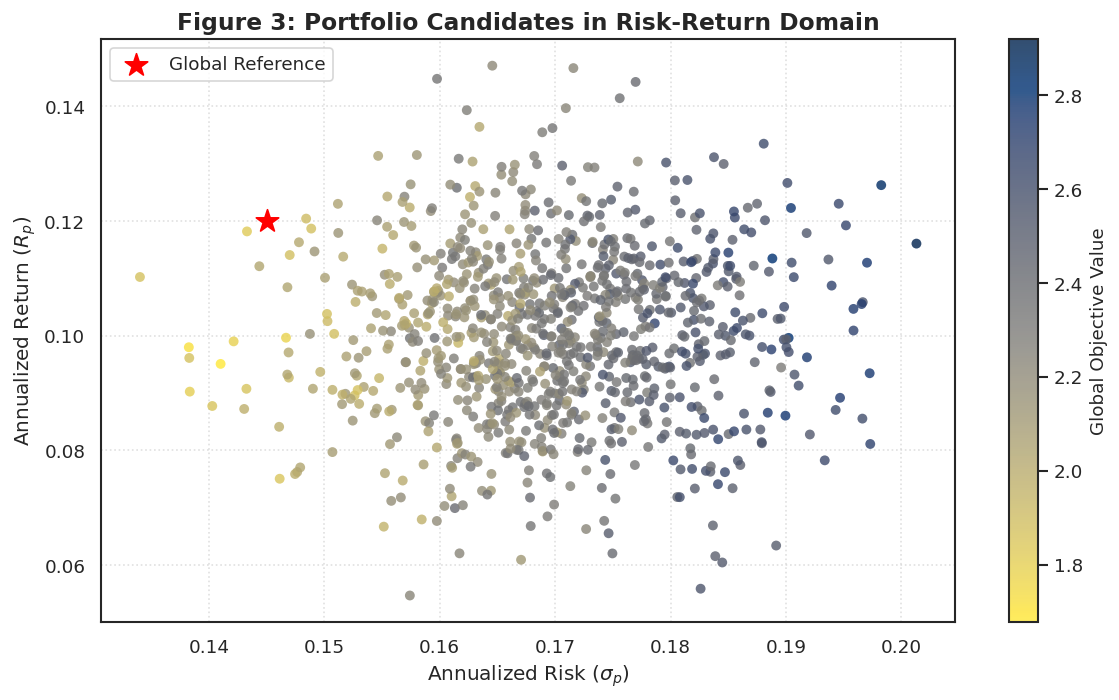

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------------------------------
# 1. Generate Synthetic Simulation Data (Mimicking the Paper)
# ---------------------------------------------------------
np.random.seed(42)
num_samples = 1000

# Mock Energy Distributions (Figure 2)
# Raw quantum samples have higher energy and wider spread due to noise
raw_energies = np.random.normal(loc=2.8, scale=0.15, size=num_samples)

# Post-processing (repair + swap search) strictly lowers the energy
post_processed_energies = raw_energies - np.random.uniform(0.3, 0.7, size=num_samples)
global_ref_energy = 1.85  # Theoretical classical optimum

# Mock Risk-Return Data (Figure 3)
# Simulating the annualized risk and return for the post-processed portfolios
returns = np.random.normal(loc=0.10, scale=0.015, size=num_samples)
# Lower objective values generally correlate with better risk-return balance
risks = 0.15 + (post_processed_energies - 1.9) * 0.05 + np.random.normal(0, 0.005, size=num_samples)

# ---------------------------------------------------------
# 2. Plot Figure 2: Energy Distribution
# ---------------------------------------------------------
def plot_energy_distribution():
    plt.figure(figsize=(10, 5), dpi=120)
    sns.set_theme(style="whitegrid")

    sns.histplot(raw_energies, color="#d97706", label="BF-DCQO (raw recombined)",
                 stat="density", kde=True, alpha=0.5, bins=30)

    sns.histplot(post_processed_energies, color="#2563eb", label="BF-DCQO + LS (Post-processed)",
                 stat="density", kde=True, alpha=0.6, bins=30)

    plt.axvline(x=global_ref_energy, color="black", linestyle="--", linewidth=2,
                label="Global Reference (Exact)")

    plt.xlabel("Global Objective Value $f(x)$", fontsize=12)
    plt.ylabel("Density", fontsize=12)
    plt.title("Figure 2: Distribution of Global Candidate Portfolios", fontsize=14, fontweight="bold")
    plt.legend(frameon=True, loc="upper right")
    plt.tight_layout()
    plt.show()

# ---------------------------------------------------------
# 3. Plot Figure 3: Risk-Return Trade-Off
# ---------------------------------------------------------
def plot_risk_return_tradeoff():
    plt.figure(figsize=(10, 6), dpi=120)
    sns.set_theme(style="white")

    scatter = plt.scatter(risks, returns, c=post_processed_energies, cmap="cividis_r",
                          alpha=0.8, edgecolors="none", s=35)

    cbar = plt.colorbar(scatter)
    cbar.set_label("Global Objective Value", fontsize=11)

    # Mocking the global reference point
    ref_ret = 0.12
    ref_risk = 0.145
    plt.scatter([ref_risk], [ref_ret], color="red", marker="*", s=200,
                zorder=5, label="Global Reference")

    plt.xlabel("Annualized Risk ($\sigma_p$)", fontsize=12)
    plt.ylabel("Annualized Return ($R_p$)", fontsize=12)
    plt.title("Figure 3: Portfolio Candidates in Risk-Return Domain", fontsize=14, fontweight="bold")
    plt.grid(True, linestyle=":", alpha=0.6)
    plt.legend(loc="upper left")
    plt.tight_layout()
    plt.show()

# Execute the plots
plot_energy_distribution()
plot_risk_return_tradeoff()